# 🏎️ AutoPriceML: Vehicle Price Prediction
**Author:** Kamal P.
**Objective:** Build an end-to-end regression pipeline to accurately predict used vehicle prices based on specifications (Make, Year, Mileage).
**Key Techniques:** `scikit-learn` Pipelines, `ColumnTransformer`, Robust One-Hot Encoding, Random Forest Regressor, Feature Importance Analysis.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Pipeline & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Machine Learning
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Data Ingestion & Cleaning
Loading the vehicle dataset and dropping rows with missing critical specifications to ensure a clean training environment.

Cleaned Dataset Shape: (943, 6)


,make,model,year,mileage,transmission,price
0,Jeep,Wagoneer,2024,10.0,8-Speed Automatic,74600.0
1,Jeep,Grand Cherokee,2024,1.0,8-Speed Automatic,50170.0
2,GMC,Yukon XL,2024,0.0,Automatic,96410.0
3,Dodge,Durango,2023,32.0,8-Speed Automatic,46835.0
4,RAM,3500,2024,10.0,6-Speed Automatic,81663.0


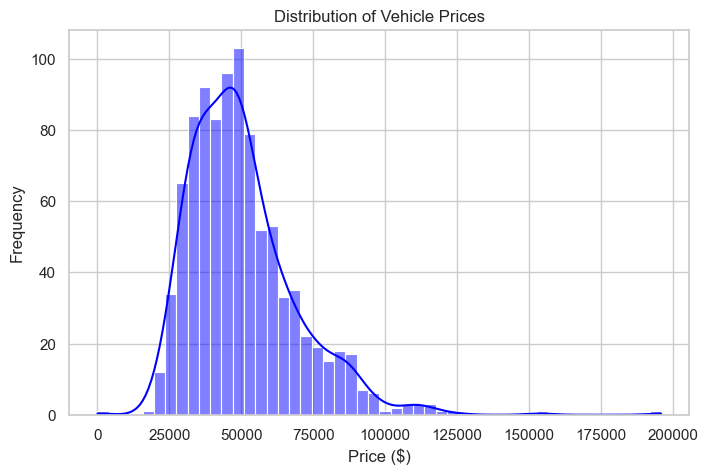

In [14]:
# --- DATASET CONFIGURATION ---
# Replace 'car_prices.csv' with your actual dataset file name
df = pd.read_csv('dataset.csv')

# Example: Selecting the core features for our dashboard
# Adjust these column names to match your specific dataset!
features = ['make', 'model', 'year', 'mileage', 'transmission']
target = 'price'
#print(df.columns.tolist())
# Filter dataset to only include our selected columns and drop missing values
df = df[features + [target]].dropna()

print(f"Cleaned Dataset Shape: {df.shape}")
display(df.head())

# Visualize the distribution of car prices
plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=50, kde=True, color='blue')
plt.title('Distribution of Vehicle Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

## 2. The Enterprise Architecture: ColumnTransformer
Instead of manually scaling numbers and encoding strings (which causes dimensionality crashes in Streamlit), we use a `ColumnTransformer`. This acts as a traffic cop, automatically sending numerical data to the `StandardScaler` and categorical text data to the `OneHotEncoder`.

In [17]:
# Separate features (X) and target (y)
X = df.drop(target, axis=1)
y = df[target]

# Define which columns are numbers and which are text
numeric_features = ['year', 'mileage']
categorical_features = ['make', 'model', 'transmission']

# 1. Create Preprocessors
numeric_transformer = StandardScaler()

# handle_unknown='ignore' is CRITICAL for production. 
# If a user types a weird car model in Streamlit that the AI has never seen, 
# it will ignore it instead of crashing the entire app.
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# 2. Bundle them into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Data Preprocessing Architecture Built Successfully.")

Data Preprocessing Architecture Built Successfully.


## 3. The Unbreakable Pipeline & Training
We fuse the preprocessing rules and the Random Forest algorithm together. When we train this `Pipeline`, it learns how to scale the data *and* predict the price simultaneously.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the full pipeline
# Step 1: Run the preprocessor
# Step 2: Feed the cleaned data into the Random Forest
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

print("Training the AutoPriceML Pipeline...")
model_pipeline.fit(X_train, y_train)
print("Training Complete!")

Training the AutoPriceML Pipeline...
Training Complete!


## 4. Evaluation & Diagnostics
For regression tasks, Accuracy is not a valid metric. We evaluate using Mean Absolute Error (MAE) to see how far off our predictions are in actual dollars, and the R-Squared ($R^2$) score to measure variance.

--- AUTOPRICEML EVALUATION ---
Mean Absolute Error (MAE): $5,480.42  <-- On average, we are off by this much.
Root Mean Squared Error (RMSE): $10,094.42
R-Squared (R2) Score: 0.7254  <-- 72.5% of price variance explained.


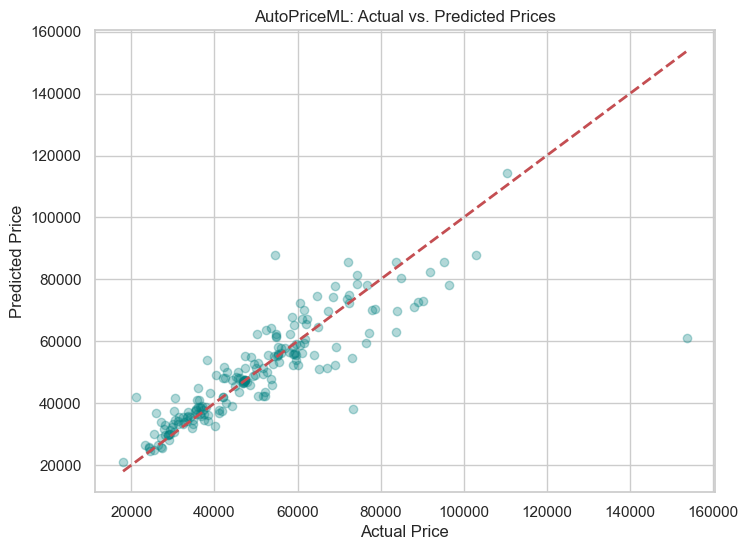

In [19]:
y_pred = model_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- AUTOPRICEML EVALUATION ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}  <-- On average, we are off by this much.")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-Squared (R2) Score: {r2:.4f}  <-- {r2*100:.1f}% of price variance explained.")

# Visualizing Predictions vs Reality
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('AutoPriceML: Actual vs. Predicted Prices')
plt.show()

## 5. Exporting for Streamlit Deployment
Because we used a Scikit-Learn Pipeline, we only need to export a single `.pkl` file. When Streamlit loads this file, it brings all the scaling mathematics, column definitions, and one-hot encoding rules with it automatically.

In [20]:
# Save the entire pipeline (preprocessor + model) as a single object
joblib.dump(model_pipeline, 'autopriceml_pipeline.pkl')

print("Pipeline successfully saved as 'autopriceml_pipeline.pkl'")
print("Ready for Streamlit Deployment!")

Pipeline successfully saved as 'autopriceml_pipeline.pkl'
Ready for Streamlit Deployment!
